---
title: Independent fits, fast — a Laplace approximation
subtitle: The same no-pooling GEV as notebook 04, fit in seconds instead of minutes
short_title: No pooling (Laplace)
authors:
  - name: Juan Emmanuel Johnson
date: 2026-06-06
keywords:
  - Laplace approximation
  - no pooling
  - GEV
  - masked likelihood
  - return levels
abstract: |
  Notebook 04 fit every station independently with NUTS — honest, but on the full
  century-long Iberian record (107 stations, ragged) a single fit takes minutes,
  and it needed careful reparameterising just to stop the sampler diverging. Here
  we fit the *same* no-pooling model with a **Laplace approximation**: optimise to
  the posterior mode and read the covariance off the curvature there. It returns
  in seconds, and lands on the same maps and the same signal-to-noise verdict —
  location μ(s) is real geography, the tail ξ(s) is mostly noise. Laplace is the
  workhorse we lean on for the heavier pooled and spatial models that follow; this
  notebook calibrates it against the NUTS baseline of notebook 04.
---

# Independent fits, fast: a Laplace approximation

Notebook 04 established the **no-pooling** baseline — one GEV per station, fit
jointly with NUTS — and its verdict: the location $\mu(s)$ is smooth and real,
while the scale and especially the tail $\xi(s)$ are dominated by sampling noise.
It also cost a few minutes per fit on the full record and needed a careful
$\log\sigma$ / bounded-$\xi$ reparameterisation to keep the sampler off the GEV's
support edge.

For everything from here on we switch the workhorse inference to a **Laplace
approximation**: find the posterior mode (the MAP) by optimisation, then
approximate the posterior by the Gaussian whose covariance is the inverse Hessian
at that mode. One optimisation, a few seconds, and — when the posterior is
roughly Gaussian — an answer that matches full MCMC. This notebook fits the exact
same no-pooling model that way and checks it lands where notebook 04's NUTS run
did.

The model is unchanged: per-station $\mu_s$, $\log\sigma_s$ and
$\xi_s = \tfrac12\tanh\tilde\xi_s$, with the likelihood **masked** over the ragged
records (each station is seen in a different subset of the 1897–2025 years).

In [1]:
import sys
import pathlib

try:
    import spatial_extremes  # noqa: F401  installed editable in the project venv
except ModuleNotFoundError:
    _here = pathlib.Path.cwd().resolve()
    _roots = (_here, *_here.parents)
    _cands = [r / "src" for r in _roots]
    _cands += [r / "projects" / "spatial_extremes" / "src" for r in _roots]
    _src = next((c for c in _cands if (c / "spatial_extremes").exists()), None)
    if _src is None:
        raise RuntimeError("cannot locate spatial_extremes/src") from None
    sys.path.insert(0, str(_src))

In [2]:
import jax
jax.config.update("jax_enable_x64", True)

In [3]:
import time

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import optax
import matplotlib.pyplot as plt

import numpyro
import numpyro.distributions as ndist
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoLaplaceApproximation
from numpyro.infer.initialization import init_to_median

from xtremax import GeneralizedExtremeValueDistribution as GEV
from spatial_extremes import data
from spatial_extremes.viz import iberia_axes, scatter_field

maxima, stations, years, is_real = data.load_annual_maxima(min_years=20)
Y = jnp.asarray(maxima)              # (S, T) — NaN where a station-year is missing
mask = ~jnp.isnan(Y)
lon, lat = stations[:, 0], stations[:, 1]
S, T = Y.shape
ybar = jnp.asarray(np.nanmean(maxima, axis=1))
ystd = jnp.asarray(np.nanstd(maxima, axis=1))
n_obs = np.asarray(mask.sum(1))
print("source:", "REAL" if is_real else "SYNTHETIC",
      "| stations", S, "| years", f"{years.min()}-{years.max()}", f"({T})")
print(f"coverage: {int(n_obs.min())}-{int(n_obs.max())} yrs/station, "
      f"{100 * float(mask.mean()):.0f}% of the {S}×{T} grid observed")

/home/azureuser/localfiles/research/research_notebook/.claude/worktrees/spatial-extremes-refresh/projects/spatial_extremes/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


source: REAL | stations 107 | years 1897-2025 (125)
coverage: 23-120 yrs/station, 49% of the 107×125 grid observed


## The model and the Laplace fit

Same no-pooling model as notebook 04 — fixed per-station priors, no parameter
shared across stations — with the stabilising $\log\sigma$ / bounded-$\xi$
reparameterisation and a **masked** likelihood that sums $\log p(y_{s,t})$ only
over observed station-years (gaps filled with an in-support value and zeroed out
via `numpyro.factor`).

`AutoLaplaceApproximation` optimises this to its MAP and reads the Gaussian
posterior off the curvature. We drive it with Adam (guarding the occasional
out-of-support GEV gradient); the ELBO loss should settle onto a flat plateau —
the sign it has found the mode.

Laplace fit 107 stations in 10.3s (NUTS in notebook 04 took several minutes)


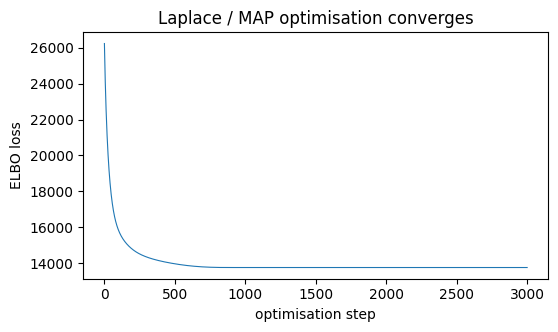

In [4]:
def gev_no_pool(Y):
    with numpyro.plate("stations", S):
        mu = numpyro.sample("mu", ndist.Normal(ybar, 5.0))
        log_sigma = numpyro.sample("log_sigma", ndist.Normal(jnp.log(ystd), 0.5))
        xi_t = numpyro.sample("xi_t", ndist.Normal(0.0, 0.5))
        sigma = numpyro.deterministic("sigma", jnp.exp(log_sigma))
        xi = numpyro.deterministic("xi", 0.5 * jnp.tanh(xi_t))
    # masked likelihood: only observed (non-NaN) station-years contribute
    yf = jnp.where(mask, Y, ybar[:, None])
    lp = GEV(loc=mu[:, None], scale=sigma[:, None],
             concentration=xi[:, None]).log_prob(yf)
    numpyro.factor("obs", jnp.where(mask, lp, 0.0).sum())

guide = AutoLaplaceApproximation(gev_no_pool, init_loc_fn=init_to_median)
opt = numpyro.optim.optax_to_numpyro(
    optax.chain(optax.zero_nans(), optax.clip_by_global_norm(10.0), optax.adam(3e-3))
)
svi = SVI(gev_no_pool, guide, opt, Trace_ELBO())
t0 = time.time()
res = svi.run(jr.PRNGKey(0), 3000, Y, progress_bar=False)
print(f"Laplace fit {S} stations in {time.time() - t0:.1f}s "
      f"(NUTS in notebook 04 took several minutes)")

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(np.asarray(res.losses), lw=0.8)
ax.set_xlabel("optimisation step")
ax.set_ylabel("ELBO loss")
ax.set_title("Laplace / MAP optimisation converges")
plt.show()

## Read off the posterior

Draw from the Laplace Gaussian with `guide.sample_posterior`, then push the draws
through `Predictive` to get posterior samples of $\mu, \sigma, \xi$ per station.

In [5]:
lap = guide.sample_posterior(jr.PRNGKey(1), res.params, sample_shape=(800,))
pred = Predictive(gev_no_pool, posterior_samples=lap,
                  return_sites=["mu", "sigma", "xi"])(jr.PRNGKey(2), Y)

def summarise(name):
    a = np.asarray(pred[name])
    return (np.median(a, 0),
            np.quantile(a, 0.025, 0),
            np.quantile(a, 0.975, 0))

mu_med, mu_lo, mu_hi = summarise("mu")
sig_med, sig_lo, sig_hi = summarise("sigma")
xi_med, xi_lo, xi_hi = summarise("xi")
print("μ  median range:", mu_med.round(1).min(), "->", mu_med.round(1).max(), "°C")
print("σ  median range:", sig_med.round(2).min(), "->", sig_med.round(2).max(), "°C")
print("ξ  median range:", xi_med.round(2).min(), "->", xi_med.round(2).max())

μ  median range: 21.3 -> 42.3 °C
σ  median range: 0.88 -> 4.31 °C
ξ  median range: -0.42 -> 0.22


## The maps

Posterior-median $\mu$, $\sigma$, $\xi$ — location on a temperature scale, scale
on `viridis`, shape on `plasma`. As in notebook 04, $\mu$ reads as a *map* and
$\xi$ reads as *static*.

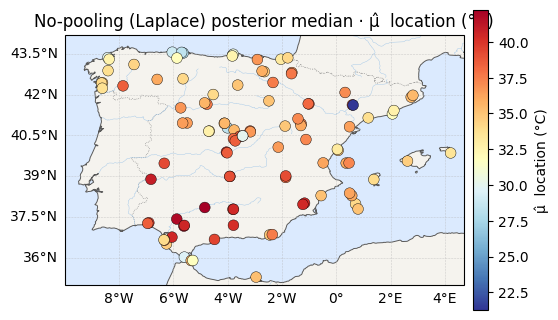

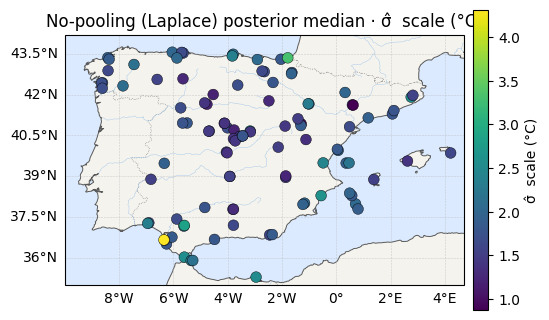

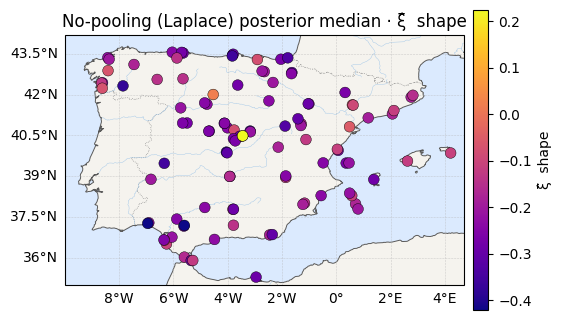

In [6]:
for vals, label, cmap in [(mu_med, "μ̂  location (°C)", "RdYlBu_r"),
                          (sig_med, "σ̂  scale (°C)", "viridis"),
                          (xi_med, "ξ̂  shape", "plasma")]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    ax.set_title(f"No-pooling (Laplace) posterior median · {label}")
    plt.show()

## The same signal-to-noise verdict

The diagnostic from notebook 04: for each parameter, the spread of the point
estimates *across* stations (signal) over the typical *within*-station 95%
credible-interval width (noise). Above 1, the map is real; below 1, it is mostly
sampling noise. Laplace should reproduce notebook 04's ordering — $\mu$ well above
the floor, $\xi$ well below.

μ:  signal SD(med)= 3.403   noise mean-CI-width= 1.011   ratio= 3.36
σ:  signal SD(med)= 0.455   noise mean-CI-width= 0.670   ratio= 0.68
ξ:  signal SD(med)= 0.096   noise mean-CI-width= 0.306   ratio= 0.31


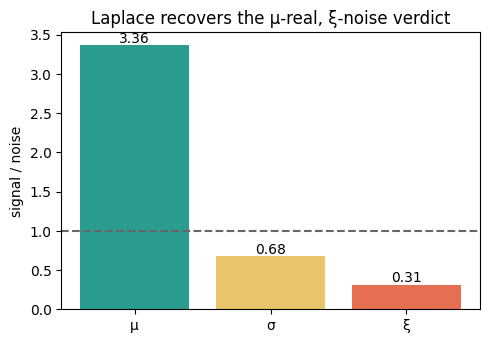

In [7]:
rows = []
for name, (med, lo, hi) in [("μ", (mu_med, mu_lo, mu_hi)),
                            ("σ", (sig_med, sig_lo, sig_hi)),
                            ("ξ", (xi_med, xi_lo, xi_hi))]:
    signal, noise = med.std(), (hi - lo).mean()
    rows.append((name, signal / noise))
    print(f"{name}:  signal SD(med)={signal:6.3f}   noise mean-CI-width={noise:6.3f}"
          f"   ratio={signal / noise:5.2f}")

fig, ax = plt.subplots(figsize=(5.4, 3.6))
names = [r[0] for r in rows]
ratios = [r[1] for r in rows]
bars = ax.bar(names, ratios, color=["#2a9d8f", "#e9c46a", "#e76f51"])
ax.axhline(1.0, ls="--", color="0.4")
ax.set_ylabel("signal / noise")
ax.set_title("Laplace recovers the μ-real, ξ-noise verdict")
for b, r in zip(bars, ratios):
    ax.text(b.get_x() + b.get_width() / 2, r + 0.03, f"{r:.2f}", ha="center")
plt.show()

## Return levels

The 100-year level at every station, with its 95% credible band — the
planner-facing summary, now in seconds.

z100 median range: 24.6 -> 47.3 °C
z100 95% CI width: 3.4 °C avg (up to 14.2)


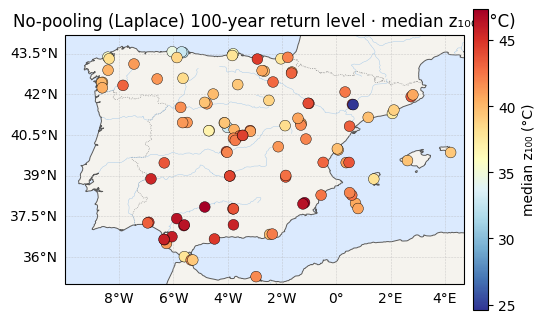

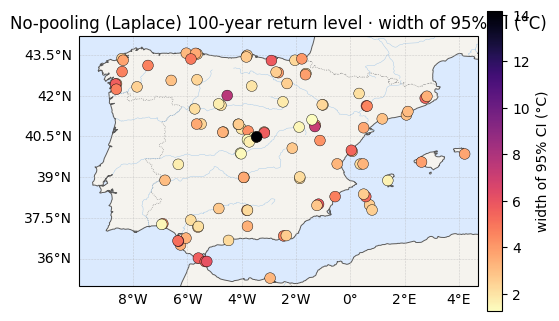

In [8]:
RL = GEV(loc=jnp.asarray(pred["mu"]), scale=jnp.asarray(pred["sigma"]),
         concentration=jnp.asarray(pred["xi"])).return_level(100.0)  # (n, S)
RL = np.asarray(RL)
rl_med = np.median(RL, 0)
rl_ciw = np.quantile(RL, 0.975, 0) - np.quantile(RL, 0.025, 0)
print(f"z100 median range: {rl_med.min():.1f} -> {rl_med.max():.1f} °C")
print(f"z100 95% CI width: {rl_ciw.mean():.1f} °C avg (up to {rl_ciw.max():.1f})")

for vals, label, cmap in [(rl_med, "median z₁₀₀ (°C)", "RdYlBu_r"),
                          (rl_ciw, "width of 95% CI (°C)", "magma_r")]:
    ax = iberia_axes(figsize=(6.2, 5.2))
    scatter_field(ax, lon, lat, vals, label=label, cmap=cmap)
    ax.set_title(f"No-pooling (Laplace) 100-year return level · {label}")
    plt.show()

## Hand-off: cache the fast fit

Ten seconds of Laplace has produced per-station estimates that NUTS spent
minutes reaching. Cache them: notebook 04 can *start* its sampler here instead
of at the prior median, and notebook 07 gets a sensible location field for
free.


In [9]:
from spatial_extremes import results

path = results.save_fit(
    "laplace_no_pool",
    source="notebooks/02_pooling/04b_many_stations_laplace.ipynb",
    is_real=is_real,
    stations=np.asarray(stations),
    mu_med=np.asarray(mu_med),        # (S,) per-station location
    sigma_med=np.asarray(sig_med),    # (S,) per-station scale
    xi_med=np.asarray(xi_med),        # (S,) per-station shape
)
print("cached ->", path)

cached -> /home/azureuser/cloudfiles/code/Users/adm.jjohnson72/scratch/cds_insitu/spatial_extremes/results/laplace_no_pool.npz


## Takeaway

Same model, same data, same conclusion as notebook 04 — $\mu$ is real geography,
$\xi$ is noise — but in **seconds rather than minutes**, and with no divergences
to wrestle (Laplace optimises; it does not sample). That speed is what makes the
pooled and spatial models in the rest of the curriculum practical on the full
century-long record.

The one caveat, as always with Laplace: a Gaussian at the mode can mis-state
interval *widths* when the true posterior is skewed — most acutely for the tail.
Where the calibrated uncertainty is the deliverable, it is worth a confirmatory
NUTS run (as in notebook 04, and the spatial notebooks' Laplace-vs-NUTS checks).
For mapping and model-building, Laplace is the right default.